Branch 6 — Macro Fundamentals
Date range : 1990-01-31 -> 2026-03-13

Indicator                         Days         Start    Current       Mean        Min        Max
----------------------------------------------------------------------------------------
  US Econ Surprise                6286    2003-01-01      27.20       5.68    -144.60     270.80
  Eurozone Surprise               6286    2003-01-01       6.30       5.72    -304.60     212.40
  China Surprise                  5981    2004-01-01      37.20       4.93    -239.00     186.20
  EM Surprise                     6285    2003-01-01      37.80       7.01    -129.50      88.20
  G10 Surprise                    6286    2003-01-01      11.70       6.23    -138.60     181.80
  US ISM Manufacturing            1732    1990-01-31      52.60      52.20      34.50      63.80
  US ISM Services                 1372    1997-07-31      53.80      54.69      37.80      67.50
  China Caixin PMI                1012    2005-01-31      49.30   

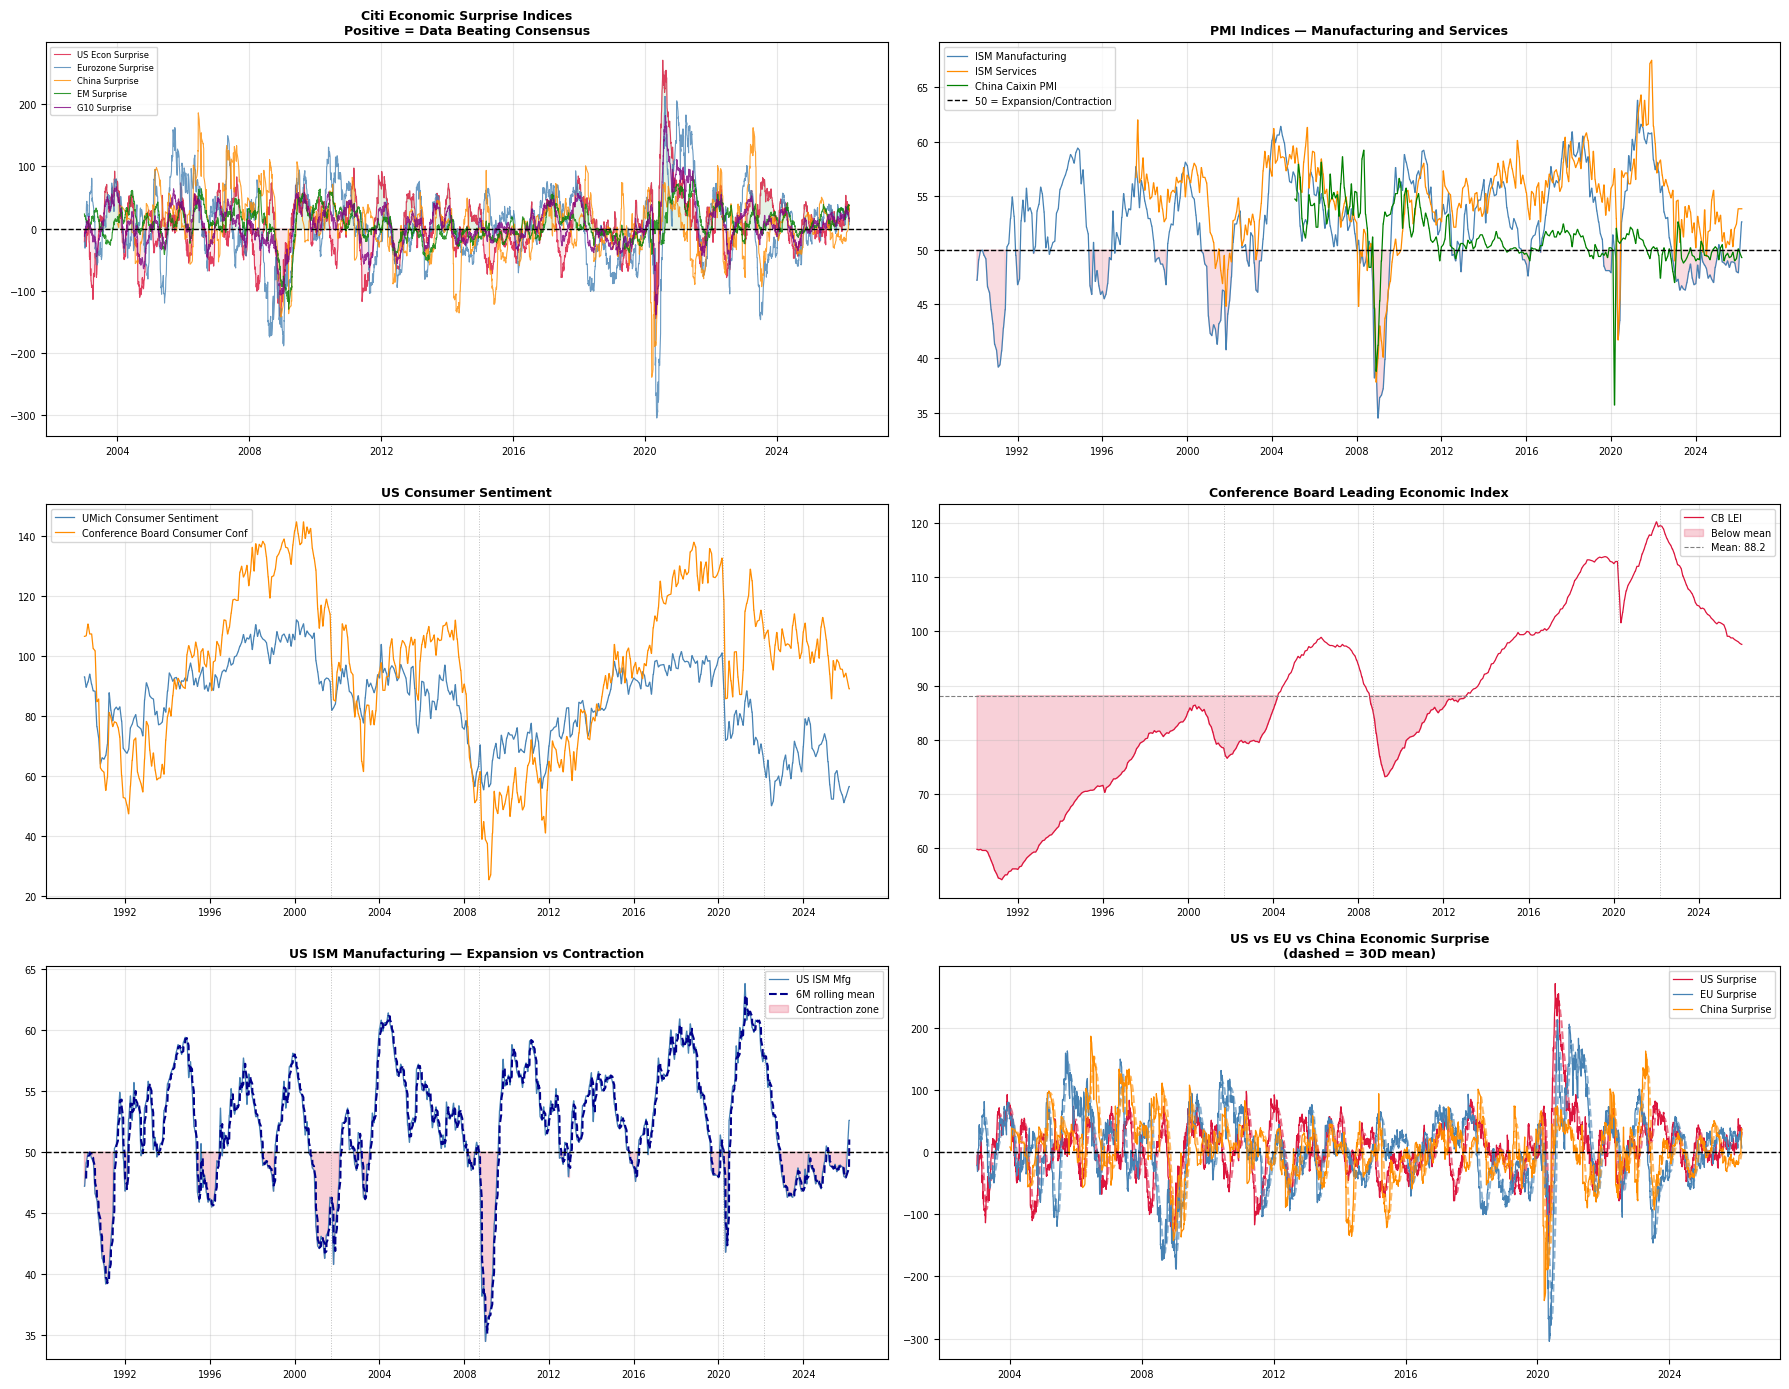


Chart saved: C:\Users\sarda\Desktop\GlobalMacroPulse\outputs\charts\07_branch6_macro_overview.png


In [2]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = r"C:\Users\sarda\Desktop\GlobalMacroPulse"
sys.path.insert(0, os.path.join(PROJECT_ROOT, "config"))
import settings as cfg

# ── Load prices and returns ───────────────────────────────────────────────────
prices  = pd.read_csv(cfg.ALIGNED_PRICES_FILE,  index_col="date", parse_dates=True)
returns = pd.read_csv(cfg.MASTER_RETURNS_FILE,   index_col="date", parse_dates=True)

# ── Define macro universe ─────────────────────────────────────────────────────
SURPRISE_INDICES = {
    "CESIUSD Index": "US Econ Surprise",
    "CESIEUR Index": "Eurozone Surprise",
    "CESICNY Index": "China Surprise",
    "CESIEM Index":  "EM Surprise",
    "CESIG10 Index": "G10 Surprise",
}

PMI_INDICES = {
    "NAPMPMI Index": "US ISM Manufacturing",
    "NAPMNMI Index": "US ISM Services",
    "CPMINDX Index": "China Caixin PMI",
}

SENTIMENT = {
    "CONSSENT Index": "UMich Consumer Sentiment",
    "CONCCONF Index": "Conference Board Consumer",
    "LEI TOTL Index": "Conference Board LEI",
}

ALL_MACRO = {**SURPRISE_INDICES, **PMI_INDICES, **SENTIMENT}

# ── Verify all tickers exist before extracting ────────────────────────────────
available   = [t for t in ALL_MACRO.keys() if t in prices.columns]
unavailable = [t for t in ALL_MACRO.keys() if t not in prices.columns]

if unavailable:
    print(f"WARNING: {len(unavailable)} tickers not in prices — skipping:")
    for t in unavailable:
        print(f"  {t}")

# Filter ALL_MACRO to only available tickers
ALL_MACRO = {k: v for k, v in ALL_MACRO.items() if k in prices.columns}

# ── Extract macro levels ──────────────────────────────────────────────────────
macro_levels = prices[list(ALL_MACRO.keys())].copy()
macro_levels.dropna(how="all", inplace=True)

print("Branch 6 — Macro Fundamentals")
print("="*70)
print(f"Date range : {macro_levels.dropna(how='all').index.min().date()} -> "
      f"{macro_levels.dropna(how='all').index.max().date()}")
print()
print(f"{'Indicator':<32} {'Days':>5}  {'Start':>12}  "
      f"{'Current':>9}  {'Mean':>9}  {'Min':>9}  {'Max':>9}")
print("-"*88)
for ticker, name in ALL_MACRO.items():
    s = macro_levels[ticker].dropna()
    if not s.empty:
        print(f"  {name:<30} {len(s):>5}  "
              f"{str(s.index.min().date()):>12}  "
              f"{s.iloc[-1]:>9.2f}  "
              f"{s.mean():>9.2f}  "
              f"{s.min():>9.2f}  "
              f"{s.max():>9.2f}")


# ── Key macro thresholds ──────────────────────────────────────────────────────
print(f"\nKey threshold analysis:")
print("-"*55)

# PMI 50 = expansion/contraction line
for ticker, name in PMI_INDICES.items():
    if ticker not in macro_levels.columns:
        continue
    s = macro_levels[ticker].dropna()
    if not s.empty:
        cur    = s.iloc[-1]
        status = "EXPANDING"   if cur > 50 else "CONTRACTING"
        dist   = cur - 50
        print(f"  {name:<30} {cur:>6.1f}  [{status}]  ({dist:>+.1f} from 50)")

# CESI: positive = data beating consensus
print()
for ticker, name in SURPRISE_INDICES.items():
    if ticker not in macro_levels.columns:
        continue
    s = macro_levels[ticker].dropna()
    if not s.empty:
        cur    = s.iloc[-1]
        status = "BEATING" if cur > 0 else "MISSING"
        print(f"  {name:<30} {cur:>8.1f}  [{status} consensus]")

# LEI direction
if "LEI TOTL Index" in macro_levels.columns:
    lei = macro_levels["LEI TOTL Index"].dropna()
    if len(lei) >= 3:
        lei_3m_chg = lei.iloc[-1] - lei.iloc[-3]
        lei_status = "IMPROVING" if lei_3m_chg > 0 else "DETERIORATING"
        print(f"\n  LEI 3-month change      : {lei_3m_chg:>+.2f}  [{lei_status}]")


# ── Plot macro overview ───────────────────────────────────────────────────────
CRISES = [
    ("2001-09-11","9/11"),("2008-09-15","Lehman"),
    ("2020-03-16","Covid"),("2022-02-24","Ukraine"),
]

fig, axes = plt.subplots(3, 2, figsize=(18, 14))

# Top left: CESI surprise indices
ax = axes[0, 0]
colors_cesi = ["crimson","steelblue","darkorange","green","purple"]
for (ticker, name), color in zip(SURPRISE_INDICES.items(), colors_cesi):
    if ticker not in macro_levels.columns:
        continue
    s = macro_levels[ticker].dropna()
    ax.plot(s.index, s.values, lw=0.8, color=color, alpha=0.8, label=name)
ax.axhline(0, color="black", lw=1.0, ls="--")
cesi_us = macro_levels["CESIUSD Index"].dropna()
ax.fill_between(cesi_us.index, cesi_us.values, 0,
                where=cesi_us.values > 0, alpha=0.1, color="green")
ax.fill_between(cesi_us.index, cesi_us.values, 0,
                where=cesi_us.values < 0, alpha=0.1, color="crimson")
ax.set_title("Citi Economic Surprise Indices\nPositive = Data Beating Consensus",
             fontsize=9, fontweight="bold")
ax.legend(fontsize=6, loc="upper left")
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(labelsize=7)

# Top right: US ISM PMIs
ax = axes[0, 1]
if "NAPMPMI Index" in macro_levels.columns:
    s_mfg = macro_levels["NAPMPMI Index"].dropna()
    ax.plot(s_mfg.index, s_mfg.values, lw=0.9, color="steelblue",
            label="ISM Manufacturing")
    ax.fill_between(s_mfg.index, s_mfg.values, 50,
                    where=s_mfg.values < 50, alpha=0.15, color="crimson")
if "NAPMNMI Index" in macro_levels.columns:
    s_svc = macro_levels["NAPMNMI Index"].dropna()
    ax.plot(s_svc.index, s_svc.values, lw=0.9, color="darkorange",
            label="ISM Services")
if "CPMINDX Index" in macro_levels.columns:
    s_cn = macro_levels["CPMINDX Index"].dropna()
    ax.plot(s_cn.index, s_cn.values, lw=0.9, color="green",
            label="China Caixin PMI")
ax.axhline(50, color="black", lw=1.0, ls="--", label="50 = Expansion/Contraction")
ax.set_title("PMI Indices — Manufacturing and Services",
             fontsize=9, fontweight="bold")
ax.legend(fontsize=7)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(labelsize=7)

# Middle left: US Consumer Sentiment
ax = axes[1, 0]
if "CONSSENT Index" in macro_levels.columns:
    s_um = macro_levels["CONSSENT Index"].dropna()
    ax.plot(s_um.index, s_um.values, lw=0.9, color="steelblue",
            label="UMich Consumer Sentiment")
if "CONCCONF Index" in macro_levels.columns:
    s_cb = macro_levels["CONCCONF Index"].dropna()
    ax.plot(s_cb.index, s_cb.values, lw=0.9, color="darkorange",
            label="Conference Board Consumer Conf")
for crisis_date, label in CRISES:
    ax.axvline(pd.Timestamp(crisis_date), color="grey", lw=0.7, ls=":", alpha=0.5)
ax.set_title("US Consumer Sentiment",
             fontsize=9, fontweight="bold")
ax.legend(fontsize=7)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(labelsize=7)

# Middle right: Conference Board LEI
ax = axes[1, 1]
if "LEI TOTL Index" in macro_levels.columns:
    lei_s = macro_levels["LEI TOTL Index"].dropna()
    ax.plot(lei_s.index, lei_s.values, lw=0.9, color="crimson", label="CB LEI")
    ax.fill_between(lei_s.index, lei_s.values, lei_s.mean(),
                    where=lei_s.values < lei_s.mean(),
                    alpha=0.2, color="crimson", label="Below mean")
    ax.axhline(lei_s.mean(), color="grey", lw=0.8, ls="--",
               label=f"Mean: {lei_s.mean():.1f}")
for crisis_date, label in CRISES:
    ax.axvline(pd.Timestamp(crisis_date), color="grey", lw=0.7, ls=":", alpha=0.5)
ax.set_title("Conference Board Leading Economic Index",
             fontsize=9, fontweight="bold")
ax.legend(fontsize=7)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(labelsize=7)

# Bottom left: US ISM Manufacturing detail
ax = axes[2, 0]
if "NAPMPMI Index" in macro_levels.columns:
    s_mfg = macro_levels["NAPMPMI Index"].dropna()
    ax.plot(s_mfg.index, s_mfg.values, lw=0.9, color="steelblue",
            label="US ISM Mfg")
    # Rolling 6-month mean
    ax.plot(s_mfg.rolling(6).mean().index,
            s_mfg.rolling(6).mean().values,
            lw=1.5, color="darkblue", ls="--",
            label="6M rolling mean")
    ax.fill_between(s_mfg.index, s_mfg.values, 50,
                    where=s_mfg.values < 50,
                    alpha=0.2, color="crimson", label="Contraction zone")
    ax.axhline(50, color="black", lw=1.0, ls="--")
for crisis_date, label in CRISES:
    ax.axvline(pd.Timestamp(crisis_date), color="grey", lw=0.7, ls=":", alpha=0.5)
ax.set_title("US ISM Manufacturing — Expansion vs Contraction",
             fontsize=9, fontweight="bold")
ax.legend(fontsize=7)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(labelsize=7)

# Bottom right: US vs EU vs China CESI
ax = axes[2, 1]
for ticker, name, color in [
    ("CESIUSD Index", "US Surprise",     "crimson"),
    ("CESIEUR Index", "EU Surprise",     "steelblue"),
    ("CESICNY Index", "China Surprise",  "darkorange"),
]:
    if ticker in macro_levels.columns:
        s = macro_levels[ticker].dropna()
        ax.plot(s.index, s.values, lw=0.9, color=color, label=name)
        ax.plot(s.rolling(30).mean().index,
                s.rolling(30).mean().values,
                lw=1.5, color=color, ls="--", alpha=0.6)
ax.axhline(0, color="black", lw=1.0, ls="--")
ax.set_title("US vs EU vs China Economic Surprise\n(dashed = 30D mean)",
             fontsize=9, fontweight="bold")
ax.legend(fontsize=7)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(labelsize=7)

plt.tight_layout()
chart_path = os.path.join(cfg.OUT_PATH, "charts", "07_branch6_macro_overview.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nChart saved: {chart_path}")

Macro Z-scores (current readings):
------------------------------------------------------------

  Economic Surprise Indices:
    US Econ Surprise                 27.2  Z=+1.12  ██          [STRONG]
    Eurozone Surprise                 6.3  Z=-1.14  ██          [WEAK]
    China Surprise                   37.2  Z=+1.53  ███         [STRONG]
    EM Surprise                      37.8  Z=+1.45  ██          [STRONG]
    G10 Surprise                     11.7  Z=-0.26              [NEUTRAL]

  PMI Indices (distance from 50):
    US ISM Manufacturing             52.6  Z=+0.13  [NEUTRAL]
    US ISM Services                  53.8  Z=-0.29  [STRONG]
    China Caixin PMI                 49.3  Z=-0.54  [NEUTRAL]

  Sentiment and Leading Indicators:
    UMich Consumer Sentiment         56.4  Z=-1.09  [LOW]
    Conference Board Consumer        89.0  Z=-1.71  [LOW]
    Conference Board LEI             97.6  Z=-1.54  [LOW]

Macro Growth Score as of 2026-03-13:
  Score           : 76.0 / 100
  Regime  

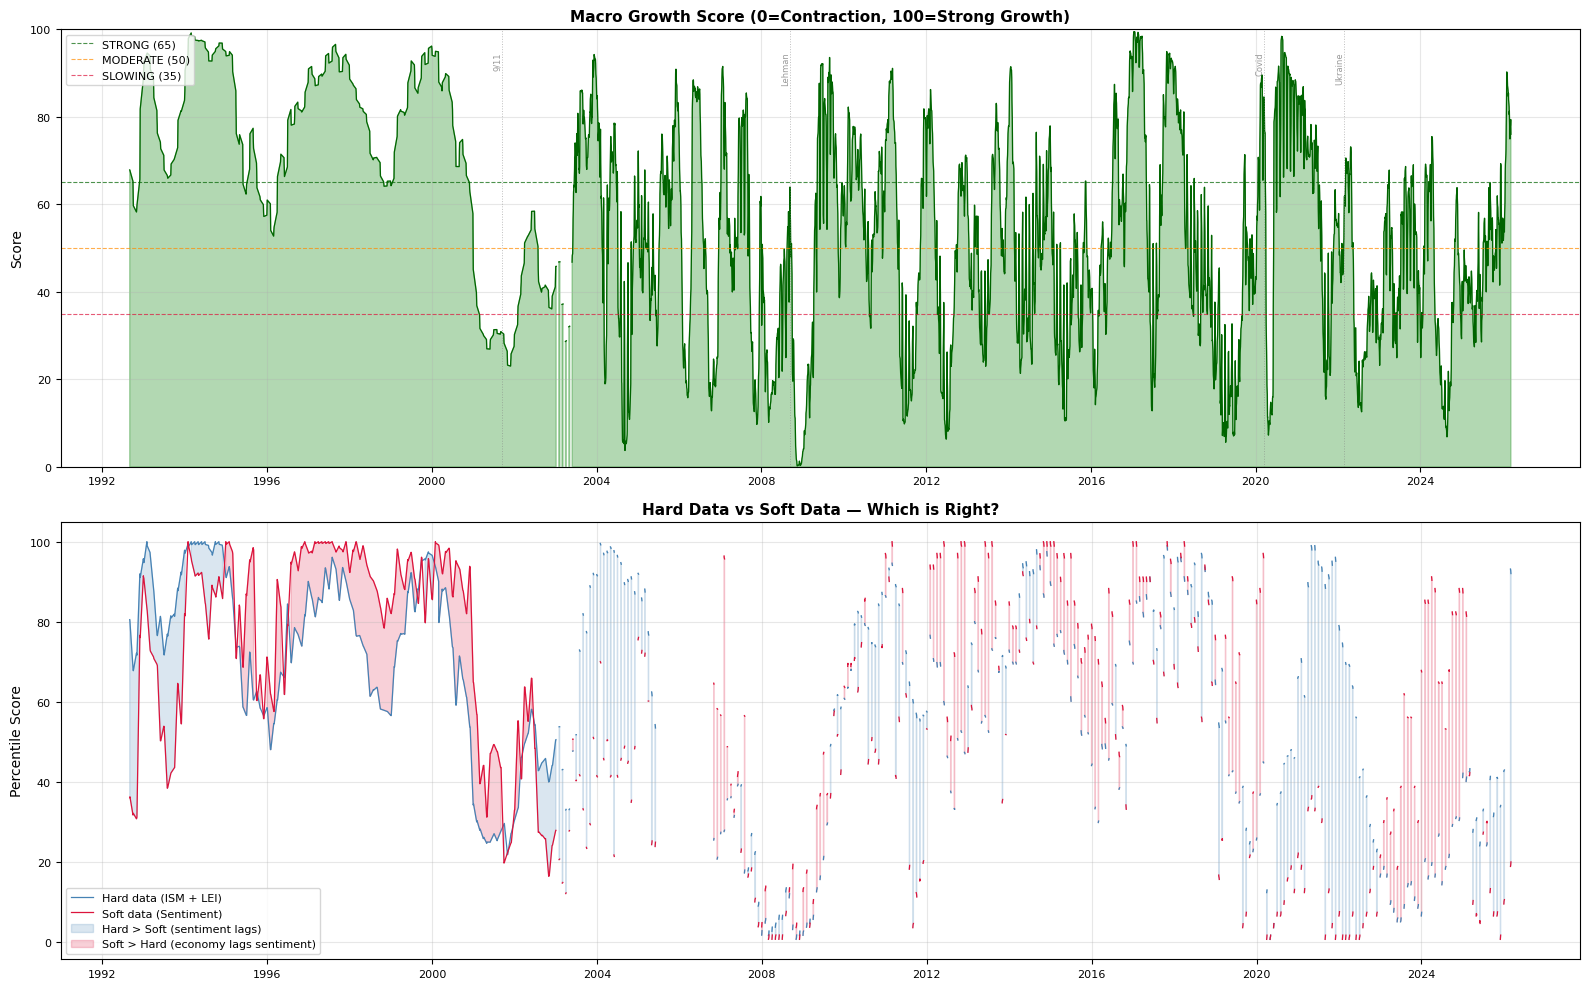


Chart saved: C:\Users\sarda\Desktop\GlobalMacroPulse\outputs\charts\07_branch6_macro_score.png
   BRANCH 6 — MACRO FUNDAMENTALS REPORT
   As of 2026-03-13

  MACRO SCORE     :  76.0 / 100
  REGIME          :  STRONG GROWTH
  REGIME STREAK   :  40 days
  ALL-TIME PCTILE :  80.7th percentile

  ── PMI Readings ────────────────────────────────────
  US ISM Manufacturing          52.6  [EXPANDING]
  US ISM Services               53.8  [EXPANDING]
  China Caixin PMI              49.3  [CONTRACTING]

  ── Economic Surprise ───────────────────────────────
  US Econ Surprise                 27.2  Z=+1.12  [BEATING]
  Eurozone Surprise                 6.3  Z=-1.14  [BEATING]
  China Surprise                   37.2  Z=+1.53  [BEATING]
  EM Surprise                      37.8  Z=+1.45  [BEATING]
  G10 Surprise                     11.7  Z=-0.26  [BEATING]

  ── Sentiment ───────────────────────────────────────
  UMich Consumer Sentiment         56.4  Z=-1.09
  Conference Board Consumer        89.0

In [4]:
# ── Cell 2: Macro Growth Score and Final Summary ─────────────────────────────
from datetime import timedelta

def rolling_zscore(series, window=252, min_periods=63):
    m = series.rolling(window, min_periods=min_periods).mean()
    s = series.rolling(window, min_periods=min_periods).std()
    return (series - m) / s

def rolling_pctile(series, window=756, min_periods=126):
    return series.rolling(window, min_periods=min_periods).apply(
        lambda x: pd.Series(x).rank(pct=True).iloc[-1] * 100, raw=False
    )

# ── 2A: Z-scores for all macro indicators ────────────────────────────────────
print("Macro Z-scores (current readings):")
print("-"*60)

print("\n  Economic Surprise Indices:")
for ticker, name in SURPRISE_INDICES.items():
    if ticker not in macro_levels.columns: continue
    s = macro_levels[ticker].dropna()
    z = rolling_zscore(s).dropna().iloc[-1]
    cur = s.iloc[-1]
    reg = "STRONG" if z > 1 else "WEAK" if z < -1 else "NEUTRAL"
    bar = "█" * min(int(abs(z)*2), 10)
    print(f"    {name:<28} {cur:>8.1f}  Z={z:>+5.2f}  {bar:<10}  [{reg}]")

print("\n  PMI Indices (distance from 50):")
for ticker, name in PMI_INDICES.items():
    if ticker not in macro_levels.columns: continue
    s = macro_levels[ticker].dropna()
    z = rolling_zscore(s).dropna().iloc[-1]
    cur = s.iloc[-1]
    reg = "STRONG" if cur > 53 else "WEAK" if cur < 48 else "NEUTRAL"
    print(f"    {name:<28} {cur:>8.1f}  Z={z:>+5.2f}  [{reg}]")

print("\n  Sentiment and Leading Indicators:")
for ticker, name in SENTIMENT.items():
    if ticker not in macro_levels.columns: continue
    s = macro_levels[ticker].dropna()
    z = rolling_zscore(s).dropna().iloc[-1]
    cur = s.iloc[-1]
    reg = "HIGH" if z > 1 else "LOW" if z < -1 else "NORMAL"
    print(f"    {name:<28} {cur:>8.1f}  Z={z:>+5.2f}  [{reg}]")


# ── 2B: Macro Growth Score (0-100) ───────────────────────────────────────────
# High score = strong growth momentum, data beating expectations
# Low score  = weak growth, data missing, leading indicators deteriorating
#
# Key inputs — all oriented so HIGH = better growth:
#   CESI US (positive = beating)
#   ISM Manufacturing (above 50 = expanding)
#   ISM Services (above 50 = expanding)
#   Consumer Sentiment (high = confident)
#   LEI level (high = leading growth)

# For CESI: percentile of level (high CESI = good)
p_cesi_us = rolling_pctile(macro_levels["CESIUSD Index"]) \
    if "CESIUSD Index" in macro_levels.columns else None

# For PMIs: percentile of level
p_ism_mfg = rolling_pctile(macro_levels["NAPMPMI Index"]) \
    if "NAPMPMI Index" in macro_levels.columns else None
p_ism_svc = rolling_pctile(macro_levels["NAPMNMI Index"]) \
    if "NAPMNMI Index" in macro_levels.columns else None
p_china_pmi = rolling_pctile(macro_levels["CPMINDX Index"]) \
    if "CPMINDX Index" in macro_levels.columns else None

# For sentiment: percentile of level
p_umich = rolling_pctile(macro_levels["CONSSENT Index"]) \
    if "CONSSENT Index" in macro_levels.columns else None
p_lei   = rolling_pctile(macro_levels["LEI TOTL Index"]) \
    if "LEI TOTL Index" in macro_levels.columns else None

# G10 CESI as global growth pulse
p_cesi_g10 = rolling_pctile(macro_levels["CESIG10 Index"]) \
    if "CESIG10 Index" in macro_levels.columns else None

# EM surprise
p_cesi_em = rolling_pctile(macro_levels["CESIEM Index"]) \
    if "CESIEM Index" in macro_levels.columns else None

MACRO_WEIGHTS = {
    "cesi_us":   0.20,
    "ism_mfg":   0.15,
    "ism_svc":   0.15,
    "china_pmi": 0.08,
    "umich":     0.12,
    "lei":       0.15,
    "cesi_g10":  0.10,
    "cesi_em":   0.05,
}

macro_score  = pd.Series(0.0, index=macro_levels.index)
weight_avail = pd.Series(0.0, index=macro_levels.index)

for series, key in [
    (p_cesi_us,   "cesi_us"),
    (p_ism_mfg,   "ism_mfg"),
    (p_ism_svc,   "ism_svc"),
    (p_china_pmi, "china_pmi"),
    (p_umich,     "umich"),
    (p_lei,       "lei"),
    (p_cesi_g10,  "cesi_g10"),
    (p_cesi_em,   "cesi_em"),
]:
    if series is None: continue
    w     = MACRO_WEIGHTS[key]
    valid = series.notna()
    macro_score[valid]  += series[valid] * w
    weight_avail[valid] += w

macro_score = macro_score / weight_avail
macro_score = macro_score.rolling(5, min_periods=1).mean()
macro_score.name = "Macro Growth Score"

def classify_macro_regime(score):
    if   score >= 65: return "STRONG GROWTH"
    elif score >= 50: return "MODERATE GROWTH"
    elif score >= 35: return "SLOWING"
    else:             return "CONTRACTION"

macro_regime = macro_score.apply(classify_macro_regime)

cur_macro   = macro_score.dropna().iloc[-1]
cur_regime  = classify_macro_regime(cur_macro)
all_time_p  = (macro_score.dropna() < cur_macro).sum() / len(macro_score.dropna()) * 100

# Regime streak
streak = 0
for r in reversed(macro_regime.dropna().values):
    if r == cur_regime:
        streak += 1
    else:
        break

print(f"\nMacro Growth Score as of {macro_score.dropna().index[-1].date()}:")
print(f"  Score           : {cur_macro:.1f} / 100")
print(f"  Regime          : {cur_regime}")
print(f"  Regime streak   : {streak} days")
print(f"  All-time pctile : {all_time_p:.1f}th percentile")
print(f"\nRegime distribution over full history:")
print(macro_regime.value_counts().to_string())


# ── 2C: The key divergence — hard data vs soft sentiment ─────────────────────
# Hard data: ISM PMIs and LEI (what the economy IS doing)
# Soft data: Consumer sentiment (how people FEEL)
# When they diverge, it signals either:
#   a) Sentiment will drag hard data down (recession coming)
#   b) Sentiment will recover to hard data (fear was overdone)

if p_ism_mfg is not None and p_umich is not None:
    hard_data_score = pd.concat([
        p_ism_mfg, p_ism_svc, p_lei
    ], axis=1).mean(axis=1)

    soft_data_score = p_umich.copy()

    hard_now = hard_data_score.dropna().iloc[-1]
    soft_now = soft_data_score.dropna().iloc[-1]
    divergence = hard_now - soft_now

    print(f"\nHard vs Soft Data Divergence:")
    print(f"  Hard data score (ISM + LEI) : {hard_now:.1f}")
    print(f"  Soft data score (Sentiment) : {soft_now:.1f}")
    print(f"  Divergence (hard - soft)    : {divergence:>+.1f}")
    if divergence > 15:
        print(f"  Signal: HARD DATA LEADING — sentiment overly pessimistic")
        print(f"          Historically resolves via sentiment recovery")
    elif divergence < -15:
        print(f"  Signal: SOFT DATA LEADING — economy may follow sentiment down")
    else:
        print(f"  Signal: ALIGNED — hard and soft data consistent")


# ── 2D: Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Top: Macro Growth Score
ax1 = axes[0]
ax1.fill_between(macro_score.index, macro_score.values, alpha=0.3, color="green")
ax1.plot(macro_score.index, macro_score.values, lw=0.9, color="darkgreen")
ax1.axhline(65, color="darkgreen",  lw=0.8, ls="--", alpha=0.7, label="STRONG (65)")
ax1.axhline(50, color="darkorange", lw=0.8, ls="--", alpha=0.7, label="MODERATE (50)")
ax1.axhline(35, color="crimson",    lw=0.8, ls="--", alpha=0.7, label="SLOWING (35)")
for crisis_date, label in CRISES:
    try:
        ax1.axvline(pd.Timestamp(crisis_date), color="grey", lw=0.7, ls=":", alpha=0.5)
        ax1.text(pd.Timestamp(crisis_date), 95, label, fontsize=6,
                 rotation=90, va="top", ha="right", color="grey", alpha=0.8)
    except: pass
ax1.set_title("Macro Growth Score (0=Contraction, 100=Strong Growth)",
              fontsize=11, fontweight="bold")
ax1.set_ylabel("Score")
ax1.legend(fontsize=8, loc="upper left")
ax1.set_ylim(0, 100)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.tick_params(labelsize=8); ax1.grid(alpha=0.3)

# Bottom: Hard vs Soft data divergence
# Bottom: Hard vs Soft data divergence
ax2 = axes[1]
if p_ism_mfg is not None and p_umich is not None:
    soft_aligned = soft_data_score.reindex(hard_data_score.index).ffill()

    ax2.plot(hard_data_score.index, hard_data_score.values,
             lw=0.9, color="steelblue", label="Hard data (ISM + LEI)")
    ax2.plot(soft_data_score.index, soft_data_score.values,
             lw=0.9, color="crimson", label="Soft data (Sentiment)")

    hard_gt_soft = hard_data_score.values > soft_aligned.values
    hard_lt_soft = hard_data_score.values < soft_aligned.values

    ax2.fill_between(hard_data_score.index,
                     hard_data_score.values,
                     soft_aligned.values,
                     where=hard_gt_soft,
                     alpha=0.2, color="steelblue",
                     label="Hard > Soft (sentiment lags)")

    ax2.fill_between(hard_data_score.index,
                     hard_data_score.values,
                     soft_aligned.values,
                     where=hard_lt_soft,
                     alpha=0.2, color="crimson",
                     label="Soft > Hard (economy lags sentiment)")

ax2.set_title("Hard Data vs Soft Data — Which is Right?",
              fontsize=11, fontweight="bold")
ax2.set_ylabel("Percentile Score")
ax2.legend(fontsize=8)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.tick_params(labelsize=8); ax2.grid(alpha=0.3)

plt.tight_layout()
chart_path = os.path.join(cfg.OUT_PATH, "charts", "07_branch6_macro_score.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nChart saved: {chart_path}")


# ── Load all previous branches ────────────────────────────────────────────────
branch1 = pd.read_csv(os.path.join(cfg.PROC_PATH, "regimes",
                      "branch1_fear_output.csv"),
                      index_col="date", parse_dates=True)
branch2 = pd.read_csv(os.path.join(cfg.PROC_PATH, "regimes",
                      "branch2_credit_output.csv"),
                      index_col="date", parse_dates=True)
branch3 = pd.read_csv(os.path.join(cfg.PROC_PATH, "regimes",
                      "branch3_equity_output.csv"),
                      index_col="date", parse_dates=True)
branch4 = pd.read_csv(os.path.join(cfg.PROC_PATH, "regimes",
                      "branch4_rates_output.csv"),
                      index_col="date", parse_dates=True)
branch5 = pd.read_csv(os.path.join(cfg.PROC_PATH, "regimes",
                      "branch5_comfx_output.csv"),
                      index_col="date", parse_dates=True)

fear_now   = branch1["fear_score"].dropna().iloc[-1]
credit_now = branch2["credit_score"].dropna().iloc[-1]
pred_now   = branch3["pred_score"].dropna().iloc[-1]
rates_now  = branch4["rates_score"].dropna().iloc[-1]
commod_now = branch5["commod_score"].dropna().iloc[-1]
macro_now  = macro_score.dropna().iloc[-1]

# Historical analogues
latest       = macro_score.dropna().index[-1]
score_series = macro_score.dropna()
diffs        = (score_series - macro_now).abs().sort_values()
diffs        = diffs[diffs.index < (latest - timedelta(days=90))]

print("=" * 65)
print("   BRANCH 6 — MACRO FUNDAMENTALS REPORT")
print(f"   As of {latest.date()}")
print("=" * 65)

print(f"\n  MACRO SCORE     :  {macro_now:.1f} / 100")
print(f"  REGIME          :  {cur_regime}")
print(f"  REGIME STREAK   :  {streak} days")
print(f"  ALL-TIME PCTILE :  {all_time_p:.1f}th percentile")

print(f"\n  ── PMI Readings ────────────────────────────────────")
for ticker, name in PMI_INDICES.items():
    if ticker not in macro_levels.columns: continue
    cur = macro_levels[ticker].dropna().iloc[-1]
    status = "EXPANDING" if cur > 50 else "CONTRACTING"
    print(f"  {name:<28} {cur:>5.1f}  [{status}]")

print(f"\n  ── Economic Surprise ───────────────────────────────")
for ticker, name in SURPRISE_INDICES.items():
    if ticker not in macro_levels.columns: continue
    cur = macro_levels[ticker].dropna().iloc[-1]
    z   = rolling_zscore(macro_levels[ticker]).dropna().iloc[-1]
    status = "BEATING" if cur > 0 else "MISSING"
    print(f"  {name:<28} {cur:>8.1f}  Z={z:>+.2f}  [{status}]")

print(f"\n  ── Sentiment ───────────────────────────────────────")
for ticker, name in SENTIMENT.items():
    if ticker not in macro_levels.columns: continue
    s = macro_levels[ticker].dropna()
    z = rolling_zscore(s).dropna().iloc[-1]
    cur = s.iloc[-1]
    print(f"  {name:<28} {cur:>8.1f}  Z={z:>+.2f}")

if p_ism_mfg is not None and p_umich is not None:
    print(f"\n  ── Hard vs Soft Divergence ─────────────────────────")
    print(f"  Hard data score  : {hard_now:.1f}")
    print(f"  Soft data score  : {soft_now:.1f}")
    print(f"  Divergence       : {divergence:>+.1f}  "
          f"({'Hard leading — sentiment overly pessimistic' if divergence > 15 else 'Aligned'})")

print(f"\n  ── Complete Branch Scorecard ───────────────────────")
print(f"  Fear     (B1) : {fear_now:>5.1f}   ACUTE")
print(f"  Credit   (B2) : {credit_now:>5.1f}   BENIGN")
print(f"  Equity   (B3) : {pred_now:>5.1f}   MODERATE")
print(f"  Rates    (B4) : {rates_now:>5.1f}   EASING")
print(f"  Commod   (B5) : {commod_now:>5.1f}   NEUTRAL/STAGFLATION")
print(f"  Macro    (B6) : {macro_now:>5.1f}   {cur_regime}")

print(f"\n  ── Historical Analogues ────────────────────────────")
shown = []
for date, diff in diffs.items():
    if all(abs((date - d).days) > 60 for d in shown):
        fear_then  = branch1["fear_score"].get(date, float("nan"))
        if "NAPMPMI Index" in macro_levels.columns:
            ism_then = macro_levels["NAPMPMI Index"].get(date, float("nan"))
        else:
            ism_then = float("nan")
        cesi_then  = macro_levels["CESIUSD Index"].get(date, float("nan")) \
            if "CESIUSD Index" in macro_levels.columns else float("nan")
        print(f"  {str(date.date())}  Macro={score_series.get(date,0):.1f}  "
              f"Fear={fear_then:.1f}  "
              f"ISM={ism_then:.1f}  CESI={cesi_then:.1f}")
        shown.append(date)
    if len(shown) >= 5:
        break

# ── Save Branch 6 output ──────────────────────────────────────────────────────
branch6_output = pd.DataFrame({
    "macro_score":  macro_score,
    "macro_regime": macro_regime,
})
branch6_output.to_csv(
    os.path.join(cfg.PROC_PATH, "regimes", "branch6_macro_output.csv")
)

print("\n" + "=" * 65)
print("  Branch 6 complete. Output saved to data/processed/regimes/")
print("=" * 65)